Requisitos

In [ ]:
!pip install medmnist

Bibliotecas usadas

In [ ]:
import matplotlib.pyplot as plt
from medmnist import PathMNIST, INFO
from torchvision import transforms
from scipy.ndimage import sobel
from scipy import signal
from pprint import pprint
import numpy as np
import torch
import math


data_flag = 'pathmnist'
info = INFO[data_flag]
print("Dataset Infos:", info)

train_dataset = PathMNIST(split='train', download=True, size=128)
print("Number of images in dataset:", len(train_dataset))

Métricas

In [ ]:
def MSE(img1, img2):
    return np.mean((img1 - img2) ** 2)

def RMSE(img1, img2):
    return np.sqrt(MSE(img1, img2))

def PSNR(img1, img2):
    mse = MSE(img1, img2)
    if (mse == 0):
        return 100

    max_pixel = 255.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))

    return psnr

def SSIM(img1, img2, window_size=11, sigma=1.5, L=255):
    C1 = (0.01 * L) ** 2
    C2 = (0.03 * L) ** 2

    ax = np.arange(-window_size // 2 + 1., window_size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    kernel = kernel / np.sum(kernel)

    mu1 = signal.convolve2d(img1, kernel, boundary='symm', mode='same')
    mu2 = signal.convolve2d(img2, kernel, boundary='symm', mode='same')

    mu1_sq = mu1 * mu1
    mu2_sq = mu2 * mu2
    mu1_mu2 = mu1 * mu2

    sigma1_sq = signal.convolve2d(img1 * img1, kernel, boundary='symm', mode='same') - mu1_sq
    sigma2_sq = signal.convolve2d(img2 * img2, kernel, boundary='symm', mode='same') - mu2_sq
    sigma12 = signal.convolve2d(img1 * img2, kernel, boundary='symm', mode='same') - mu1_mu2

    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
    return np.mean(ssim_map)

def gradient_magnitude(img):
    dx = sobel(img, axis=0, mode='reflect')
    dy = sobel(img, axis=1, mode='reflect')

    return np.hypot(dx, dy)

def GMSD(img1, img2, T=170):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    gm1 = gradient_magnitude(img1)
    gm2 = gradient_magnitude(img2)

    gms_map = (2 * gm1 * gm2 + T) / (gm1**2 + gm2**2 + T)
    gmsd_value = np.std(gms_map)

    return gmsd_value

Mostrar as três imagens escolhidas

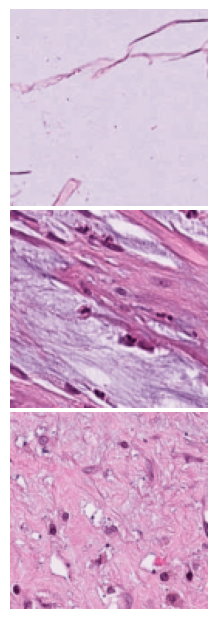

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(3, 6))

for i in range(3):
    image, label = train_dataset[i]
    image_np = np.array(image)
    axs[i].imshow(image_np)
    axs[i].axis('off')

plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0.02, hspace=0.02)
plt.show()

# Converte a imagem para gray-scale para facilitar operações de contraste
def rgb2gray(img):
    if img.ndim == 3:
        return np.dot(img[...,:3], [0.2989, 0.5870, 0.1140])
    return img

# Adiciona padding a imagem
def add_padding(image, pad_h, pad_w, constant_value=0):
    height, width = image.shape
    new_image = np.full((height + 2 * pad_h, width + 2 * pad_w), constant_value, dtype=image.dtype)
    new_image[pad_h:pad_h + height, pad_w:pad_w + width] = image
    return new_image

Ruído Sal e Pimenta

In [ ]:
# Sal e Pimenta
def add_salt_and_pepper(image, prob=0.10):
    output = np.copy(image)
    h, w = image.shape

    random_matrix = np.random.rand(h, w)
    pepper_mask = random_matrix < (prob / 2)
    salt_mask = random_matrix > 1 - (prob / 2)

    output[pepper_mask] = 0
    output[salt_mask] = 255

    return output

Operações Pontuais (Ajustes de Contraste)

In [ ]:
# Equalização de histograma
def histogram_equalization(img):
    height, width = img.shape
    total_pixels = height * width
    hist = [0] * 256
    for i in range(height):
        for j in range(width):
            hist[int(img[i, j])] += 1
    cdf = [0] * 256
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]
    cdf_normalized = [int(round((cdf[i] / total_pixels) * 255)) for i in range(256)]
    equalized_img = np.zeros_like(img, dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            equalized_img[i, j] = cdf_normalized[int(img[i, j])]
    return equalized_img

# Correção gama
def gamma_correction(img, gamma=1.0):
    height, width = img.shape
    corrected_img = np.zeros_like(img, dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            normalized = img[i, j] / 255.0
            corrected = math.pow(normalized, 1/gamma)
            corrected_img[i, j] = int(round(corrected * 255))
    return corrected_img

Redução de Esmaecimento (Filtragem Espacial – Aguçamento)

In [ ]:
# Função de convolução
def convolve2d(image, kernel):
    k_h, k_w = kernel.shape
    pad_h = k_h // 2
    pad_w = k_w // 2
    padded = add_padding(image, pad_h, pad_w, constant_value=0)
    output = np.zeros_like(image, dtype=np.float64)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+k_h, j:j+k_w]
            output[i, j] = np.sum(region * kernel)
    return output

# Definição dos Kernels Laplacianos
laplacian_kernel = np.array([[ 0, -1,  0],
                             [-1,  4, -1],
                             [ 0, -1,  0]])
averaging_kernel = np.ones((3, 3)) / 9.0

# Filtro Laplaciano
def laplacian_filter(image, alpha = 0.5): # aplicando um alpha para o filtro não ser tão agressivo
    laplacian_img = convolve2d(image, laplacian_kernel)
    sharpened = image - alpha * laplacian_img
    sharpened = np.clip(sharpened, 0, 255)
    return sharpened

def sobel_filter(img):
    kernel_x = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ])
    kernel_y = np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]
    ])

    img_height, img_width = img.shape

    padded_img = np.pad(img, pad_width=1, mode='edge')
    output_img = np.zeros((img_height, img_width), dtype=float)

    for i in range(1, img_height + 1):
        for j in range(1, img_width + 1):
            gx = np.sum(padded_img[i-1:i+2, j-1:j+2] * kernel_x)
            gy = np.sum(padded_img[i-1:i+2, j-1:j+2] * kernel_y)
            output_img[i-1, j-1] = abs(gx) + abs(gy)

    max_val = output_img.max()
    if max_val > 0:
        output_img = (output_img / max_val) * 255
    return output_img.astype(np.uint8)

# Filtro High-Boost
def highboost_filter(image, A=3.0):
    blurred = convolve2d(image, averaging_kernel)
    mask = image - blurred
    highboost = image + (A - 1) * mask
    highboost = np.clip(highboost, 0, 255)
    return highboost

Remoção de Ruído (Filtragem Espacial – Suavização)

In [ ]:
# Kernel Gaussiano
def gaussian_kernel(kernel_size=3, sigma=1.0):
    k = kernel_size // 2
    ax = np.linspace(-k, k, kernel_size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / np.sum(kernel)
    return kernel

# Filtro Gaussiano
def gaussian_filter(image, kernel_size=3, sigma=1.0):
    kernel = gaussian_kernel(kernel_size, sigma)
    filtered = convolve2d(image, kernel)
    filtered = np.clip(filtered, 0, 255)
    return filtered.astype(np.uint8)

# Filtro Mediana
def median_filter(image, kernel_size=3):
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='edge')
    output = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            output[i, j] = np.median(window)
    return output

Pré-Processando as imagens

In [213]:
# Carregando as imagens originais e com Sal e Pimenta
original_images = []
salt_and_pepper_images = []
num_imagens = 3

for i in range(num_imagens):
    image, label = train_dataset[i]
    gray_img = rgb2gray(np.array(image)).astype(np.uint8)
    original_images.append(gray_img)

    sp_image = add_salt_and_pepper(gray_img)
    salt_and_pepper_images.append(sp_image)

Aplicando Equalização de Histograma como ajuste de contraste

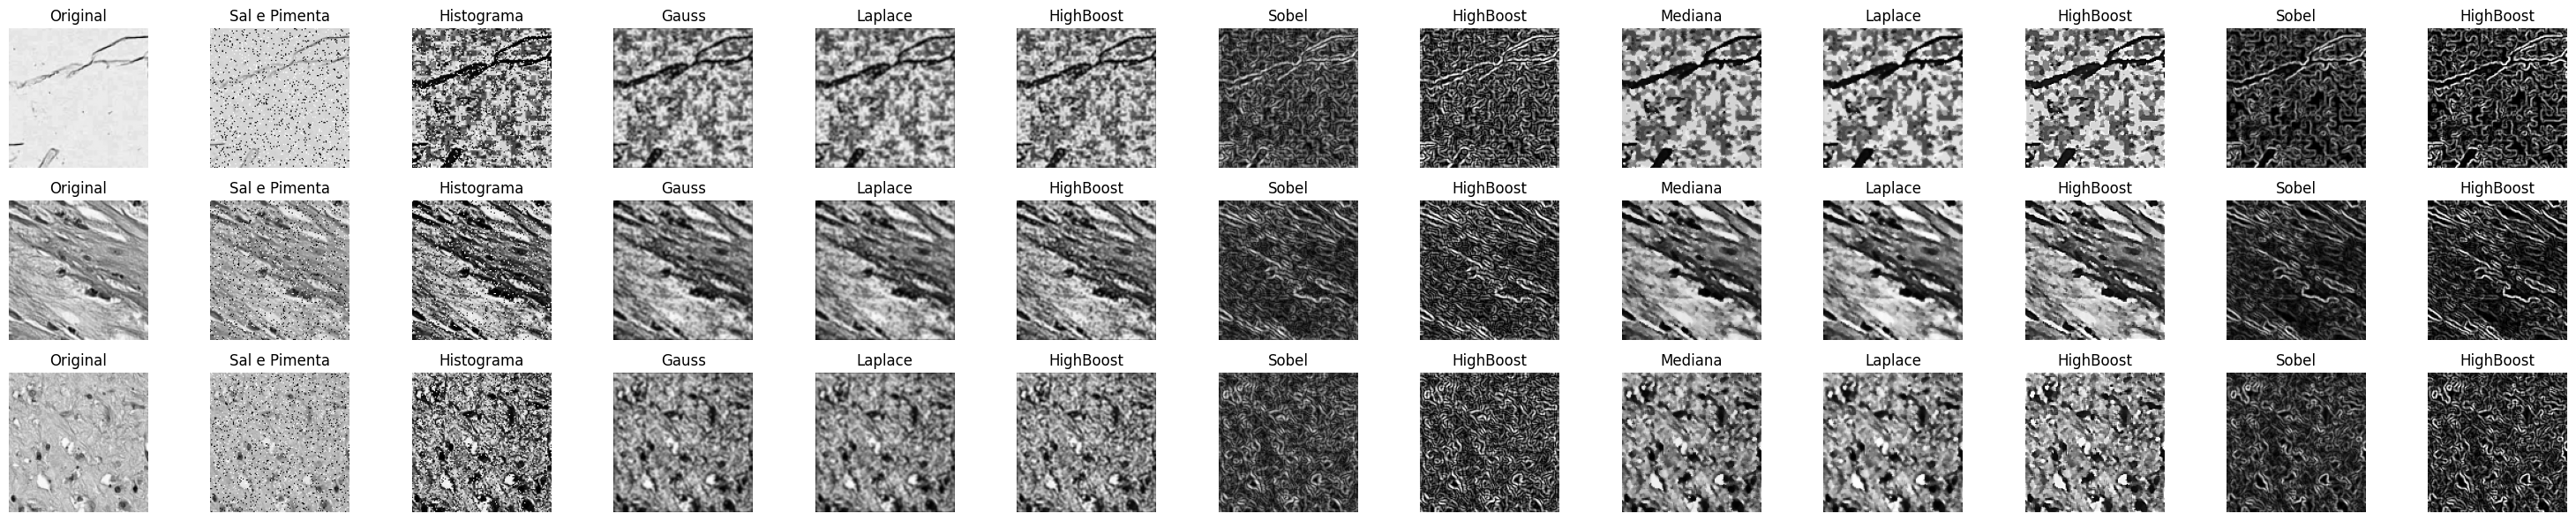

In [204]:
# Parametros
gauss_kernels = [3, 3, 3]
gauss_sigmas = [1.0, 1.0, 1.0]
median_kernels = [3, 3, 3]
lap_alpha_values = [0.05, 0.05, 0.05]
highboost_values = [2.0, 2.0, 2.0]

# Variaveis Auxiliares
hist_eq_images       = []
hist_eq_gauss        = []
hist_eq_median       = []
hist_eq_gauss_lap    = []
hist_eq_gauss_lapHB  = []
hist_eq_gauss_sob    = []
hist_eq_gauss_sobHB  = []
hist_eq_median_lap   = []
hist_eq_median_lapHB = []
hist_eq_median_sob   = []
hist_eq_median_sobHB = []

for i in range(num_imagens):
    # 1. Hist-Eq
    eq_img = histogram_equalization(salt_and_pepper_images[i])
    hist_eq_images.append(eq_img)

    # 2.2. Filtro Gaussiano a partir do Histograma Equalizado
    eq_gauss = gaussian_filter(eq_img, kernel_size=gauss_kernels[i], sigma=gauss_sigmas[i])
    hist_eq_gauss.append(eq_gauss)

    # - Laplaciano (a partir do Gaussiano)
    eq_gauss_laplace = laplacian_filter(eq_gauss, alpha=lap_alpha_values[i])
    hist_eq_gauss_lap.append(eq_gauss_laplace)
    # - HighBoost
    eq_gauss_lapHB = highboost_filter(eq_gauss_laplace, A=highboost_values[i])
    hist_eq_gauss_lapHB.append(eq_gauss_lapHB)

    # - Sobel (a partir do Gaussiano)
    eq_gauss_sobel = sobel_filter(eq_gauss)
    hist_eq_gauss_sob.append(eq_gauss_sobel)
    # - HighBoost
    eq_gauss_sobHB = highboost_filter(eq_gauss_sobel, A=highboost_values[i])
    hist_eq_gauss_sobHB.append(eq_gauss_sobHB)

    # 2.2. Filtro Mediana a partir do hist_eq
    eq_median = median_filter(eq_img, kernel_size=median_kernels[i])
    hist_eq_median.append(eq_median)

    # - Laplaciano (a partir da Mediana)
    eq_median_laplace = laplacian_filter(eq_median, alpha=lap_alpha_values[i])
    hist_eq_median_lap.append(eq_median_laplace)
    # - HighBoost
    eq_median_lapHB = highboost_filter(eq_median_laplace, A=highboost_values[i])
    hist_eq_median_lapHB.append(eq_median_lapHB)

    # - Sobel (a partir da Mediana)
    eq_median_sobel = sobel_filter(eq_median)
    hist_eq_median_sob.append(eq_median_sobel)
    # - HighBoost
    eq_median_sobHB = highboost_filter(eq_median_sobel, A=highboost_values[i])
    hist_eq_median_sobHB.append(eq_median_sobHB)

fig, axes = plt.subplots(num_imagens, 13, figsize=(30, 6))

for i in range(num_imagens):
    # 0. Original
    axes[i, 0].imshow(original_images[i], cmap='gray')
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')

    # 1. Sal e Pimenta
    axes[i, 1].imshow(salt_and_pepper_images[i], cmap='gray')
    axes[i, 1].set_title("Sal e Pimenta")
    axes[i, 1].axis('off')

    # 2. Histograma
    axes[i, 2].imshow(hist_eq_images[i], cmap='gray')
    axes[i, 2].set_title("Histograma")
    axes[i, 2].axis('off')

    # 3. Gauss (Histograma + Gauss)
    axes[i, 3].imshow(hist_eq_gauss[i], cmap='gray')
    axes[i, 3].set_title("Gauss")
    axes[i, 3].axis('off')

    # 4. Gauss + Laplaciano
    axes[i, 4].imshow(hist_eq_gauss_lap[i], cmap='gray')
    axes[i, 4].set_title("Laplace")
    axes[i, 4].axis('off')

    # 5. Gauss + Lap + HighBoost
    axes[i, 5].imshow(hist_eq_gauss_lapHB[i], cmap='gray')
    axes[i, 5].set_title("HighBoost")
    axes[i, 5].axis('off')

    # 6. Gauss + Sobel
    axes[i, 6].imshow(hist_eq_gauss_sob[i], cmap='gray')
    axes[i, 6].set_title("Sobel")
    axes[i, 6].axis('off')

    # 7. Gauss + Sobel + HighBoost
    axes[i, 7].imshow(hist_eq_gauss_sobHB[i], cmap='gray')
    axes[i, 7].set_title("HighBoost")
    axes[i, 7].axis('off')

    # 8. Mediana (Histograma + Mediana)
    axes[i, 8].imshow(hist_eq_median[i], cmap='gray')
    axes[i, 8].set_title("Mediana")
    axes[i, 8].axis('off')

    # 9. Mediana + Laplaciano
    axes[i, 9].imshow(hist_eq_median_lap[i], cmap='gray')
    axes[i, 9].set_title("Laplace")
    axes[i, 9].axis('off')

    # 10. Mediana + Lap + HighBoost
    axes[i, 10].imshow(hist_eq_median_lapHB[i], cmap='gray')
    axes[i, 10].set_title("HighBoost")
    axes[i, 10].axis('off')

    # 11. Mediana + Sobel
    axes[i, 11].imshow(hist_eq_median_sob[i], cmap='gray')
    axes[i, 11].set_title("Sobel")
    axes[i, 11].axis('off')

    # 12. Mediana + Sobel + HighBoost
    axes[i, 12].imshow(hist_eq_median_sobHB[i], cmap='gray')
    axes[i, 12].set_title("HighBoost")
    axes[i, 12].axis('off')

plt.tight_layout()
plt.show()

Aplicando Correção de Gama como ajuste de contraste

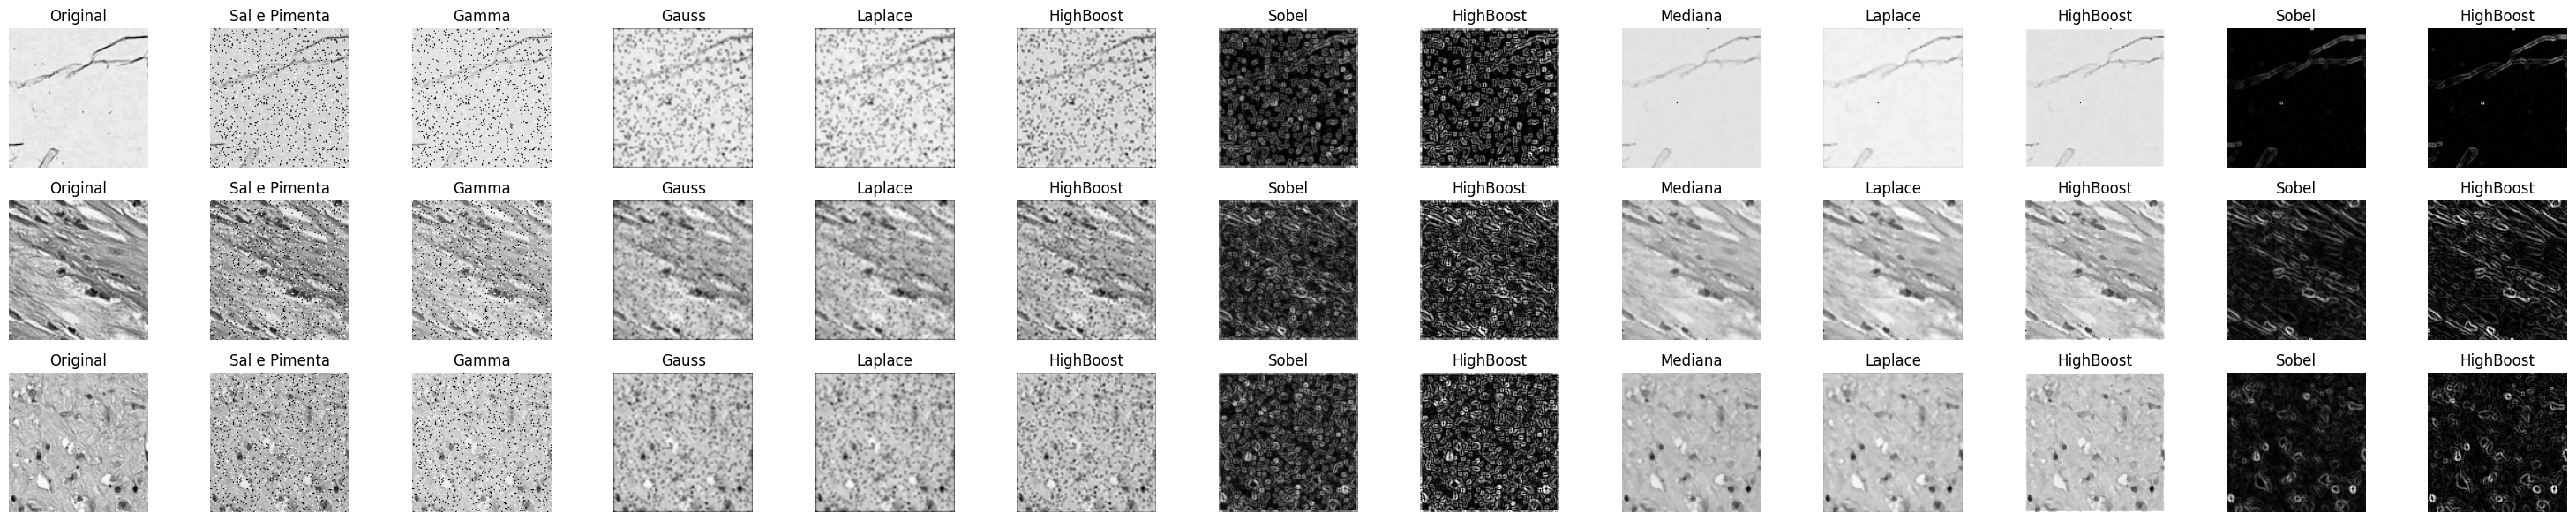

In [203]:
# Parametros
gamma_values = [1.5, 1.5, 1.5]
gauss_kernels = [3, 3, 3]
gauss_sigmas = [1.0, 1.0, 1.0]
median_kernels = [3, 3, 3]
lap_alpha_values = [0.05, 0.05, 0.05]
highboost_values = [2.0, 2.0, 2.0]

# Variaveis Auxiliares
gamma_images   = []
gamma_gauss    = []
gamma_median   = []
gamma_gauss_lap   = []
gamma_gauss_lapHB = []
gamma_gauss_sob   = []
gamma_gauss_sobHB = []
gamma_median_lap   = []
gamma_median_lapHB = []
gamma_median_sob   = []
gamma_median_sobHB = []


for i in range(num_imagens):
    # 1. Correção Gama
    gamma_img = gamma_correction(salt_and_pepper_images[i], gamma=gamma_values[i])
    gamma_images.append(gamma_img)

    # 2.1. Filtro Gaussiano (após gamma)
    g_gauss = gaussian_filter(gamma_img, kernel_size=gauss_kernels[i], sigma=gauss_sigmas[i])
    gamma_gauss.append(g_gauss)

    # - Laplaciano (a partir do Gaussiano)
    g_gauss_laplace = laplacian_filter(g_gauss, alpha=lap_alpha_values[i])
    gamma_gauss_lap.append(g_gauss_laplace)
    # - HighBoost
    g_gauss_lapHB = highboost_filter(g_gauss_laplace, A=highboost_values[i])
    gamma_gauss_lapHB.append(g_gauss_lapHB)

    # - Laplaciano (a partir do Gaussiano)
    g_gauss_sobel = sobel_filter(g_gauss)
    gamma_gauss_sob.append(g_gauss_sobel)
    # - HighBoost
    g_gauss_sobHB = highboost_filter(g_gauss_sobel, A=highboost_values[i])
    gamma_gauss_sobHB.append(g_gauss_sobHB)

    # 2.2. Filtro Mediana (após gamma)
    g_median = median_filter(gamma_img, kernel_size=3)
    gamma_median.append(g_median)

    # - Laplaciano (a partir da Mediana)
    g_median_laplace = laplacian_filter(g_median, alpha=lap_alpha_values[i])
    gamma_median_lap.append(g_median_laplace)
    # - HighBoost
    g_median_lapHB = highboost_filter(g_median_laplace, A=highboost_values[i])
    gamma_median_lapHB.append(g_median_lapHB)

    # - Sobel (a partir da Mediana)
    g_median_sobel = sobel_filter(g_median)
    gamma_median_sob.append(g_median_sobel)
    # - HighBoost
    g_median_sobHB = highboost_filter(g_median_sobel, A=highboost_values[i])
    gamma_median_sobHB.append(g_median_sobHB)

fig, axes = plt.subplots(num_imagens, 13, figsize=(30, 6))

for i in range(num_imagens):
    # 0. Original
    axes[i, 0].imshow(original_images[i], cmap='gray')
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')

    # 1. Sal e Pimenta
    axes[i, 1].imshow(salt_and_pepper_images[i], cmap='gray')
    axes[i, 1].set_title("Sal e Pimenta")
    axes[i, 1].axis('off')

    # 2. Gamma
    axes[i, 2].imshow(gamma_images[i], cmap='gray')
    axes[i, 2].set_title("Gamma")
    axes[i, 2].axis('off')

    # 3. Gauss
    axes[i, 3].imshow(gamma_gauss[i], cmap='gray')
    axes[i, 3].set_title("Gauss")
    axes[i, 3].axis('off')

    # 4. Gauss + Laplaciano
    axes[i, 4].imshow(gamma_gauss_lap[i], cmap='gray')
    axes[i, 4].set_title("Laplace")
    axes[i, 4].axis('off')

    # 5. Gauss + Lap + HighBoost
    axes[i, 5].imshow(gamma_gauss_lapHB[i], cmap='gray')
    axes[i, 5].set_title("HighBoost")
    axes[i, 5].axis('off')

    # 6. Gauss + Sobel
    axes[i, 6].imshow(gamma_gauss_sob[i], cmap='gray')
    axes[i, 6].set_title("Sobel")
    axes[i, 6].axis('off')

    # 7. Gauss + Sobel + HighBoost
    axes[i, 7].imshow(gamma_gauss_sobHB[i], cmap='gray')
    axes[i, 7].set_title("HighBoost")
    axes[i, 7].axis('off')

    # 8. Mediana
    axes[i, 8].imshow(gamma_median[i], cmap='gray')
    axes[i, 8].set_title("Mediana")
    axes[i, 8].axis('off')

    # 9. Mediana + Laplaciano
    axes[i, 9].imshow(gamma_median_lap[i], cmap='gray')
    axes[i, 9].set_title("Laplace")
    axes[i, 9].axis('off')

    # 10. Mediana + Lap + HighBoost
    axes[i, 10].imshow(gamma_median_lapHB[i], cmap='gray')
    axes[i, 10].set_title("HighBoost")
    axes[i, 10].axis('off')

    # 11. Mediana + Sobel
    axes[i, 11].imshow(gamma_median_sob[i], cmap='gray')
    axes[i, 11].set_title("Sobel")
    axes[i, 11].axis('off')

    # 12. Mediana + Sobel + HighBoost
    axes[i, 12].imshow(gamma_median_sobHB[i], cmap='gray')
    axes[i, 12].set_title("HighBoost")
    axes[i, 12].axis('off')

plt.tight_layout()
plt.show()

Métricas MSE, RMSE, PSNR, SSIM, GMSD para Equalização de Histograma


Imagem 1 Original:


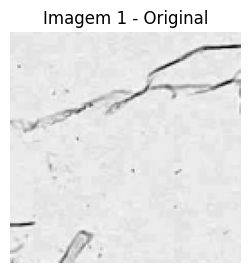


Gauss - Laplace e HighBoost


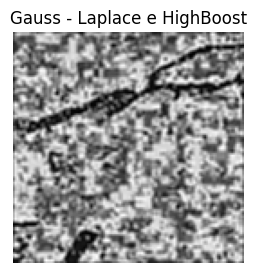

Métricas:
  MSE  : 7751.991049198103
  RMSE : 88.04539198162561
  PSNR : 9.236670982810987
  SSIM : -0.011106127603899578
  GMSD : 0.2143205314810502

Gauss - Sobel e HighBoost


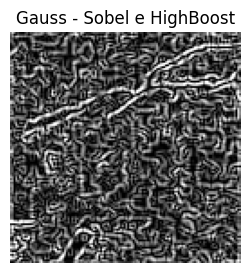

Métricas:
  MSE  : 21848.67911783854
  RMSE : 147.81298697285885
  PSNR : 4.736551744435723
  SSIM : -0.005606539465950702
  GMSD : 0.2162784831592657

Mediana - Laplace e HighBoost


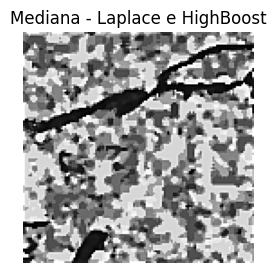

Métricas:
  MSE  : 9504.014353500177
  RMSE : 97.48853447200946
  PSNR : 8.351732773341995
  SSIM : -0.014307370963876723
  GMSD : 0.23241927775190913

Mediana - Sobel e HighBoost


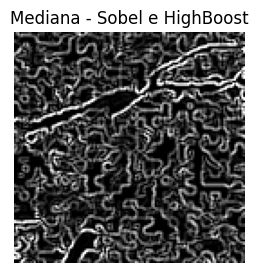

Métricas:
  MSE  : 27127.549675835504
  RMSE : 164.70443125743614
  PSNR : 3.796697934359438
  SSIM : -0.006837835847321925
  GMSD : 0.23402979887878225

Imagem 2 Original:


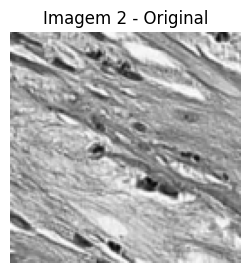


Gauss - Laplace e HighBoost


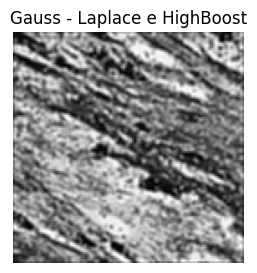

Métricas:
  MSE  : 1953.5964647985384
  RMSE : 44.1995075176018
  PSNR : 15.222455001597508
  SSIM : -0.08924224053468774
  GMSD : 0.2123951728679496

Gauss - Sobel e HighBoost


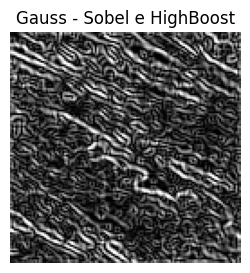

Métricas:
  MSE  : 13451.93544665678
  RMSE : 115.98247905031509
  PSNR : 6.8429558631898
  SSIM : -0.005571950492009106
  GMSD : 0.26640145571773105

Mediana - Laplace e HighBoost


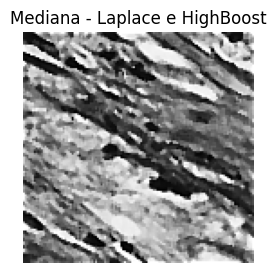

Métricas:
  MSE  : 2611.9182742818193
  RMSE : 51.106929806845365
  PSNR : 13.961207769263249
  SSIM : -0.1549311403558274
  GMSD : 0.1950161911495128

Mediana - Sobel e HighBoost


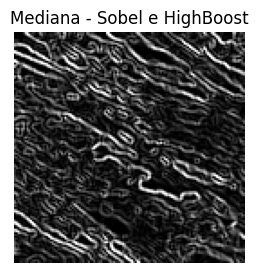

Métricas:
  MSE  : 16570.083779417437
  RMSE : 128.72483746121972
  PSNR : 5.93755656621977
  SSIM : -0.04752786900010894
  GMSD : 0.2531132398647645

Imagem 3 Original:


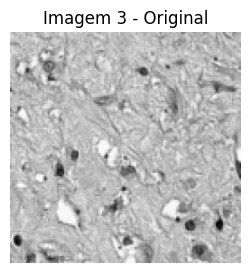


Gauss - Laplace e HighBoost


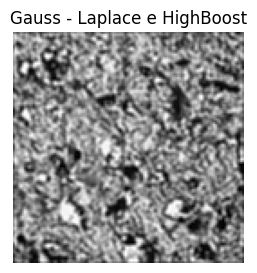

Métricas:
  MSE  : 3691.81637968652
  RMSE : 60.76031912100627
  PSNR : 12.45840268533545
  SSIM : -0.04130188455259187
  GMSD : 0.23353051561370727

Gauss - Sobel e HighBoost


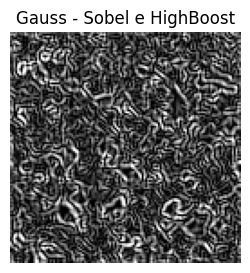

Métricas:
  MSE  : 15213.772989155332
  RMSE : 123.34412425873934
  PSNR : 6.308434291837407
  SSIM : -0.009373692779513932
  GMSD : 0.2768795765122774

Mediana - Laplace e HighBoost


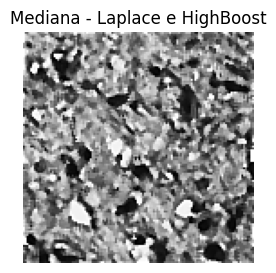

Métricas:
  MSE  : 5058.704350966465
  RMSE : 71.12456924977799
  PSNR : 11.090410624626667
  SSIM : -0.05275072229549844
  GMSD : 0.2410120318008408

Mediana - Sobel e HighBoost


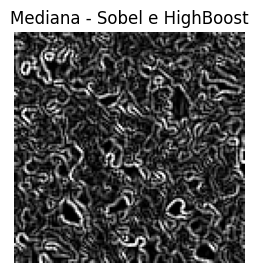

Métricas:
  MSE  : 18045.393897539303
  RMSE : 134.33314519335613
  PSNR : 5.567139945244377
  SSIM : -0.012482075049031064
  GMSD : 0.2723137810398397


In [ ]:
metrics = {}

for i in range(num_imagens):
    image_key = f"Imagem {i+1}"
    orig = original_images[i]

    # Calcula as métricas para as imagens processadas
    metrics[image_key] = {
        "Gauss - Laplace e HighBoost": {
            "MSE": MSE(orig, hist_eq_gauss_lapHB[i]),
            "RMSE": RMSE(orig, hist_eq_gauss_lapHB[i]),
            "PSNR": PSNR(orig, hist_eq_gauss_lapHB[i]),
            "SSIM": SSIM(orig, hist_eq_gauss_lapHB[i]),
            "GMSD": GMSD(orig, hist_eq_gauss_lapHB[i])
        },
        "Gauss - Sobel e HighBoost": {
            "MSE": MSE(orig, hist_eq_gauss_sobHB[i]),
            "RMSE": RMSE(orig, hist_eq_gauss_sobHB[i]),
            "PSNR": PSNR(orig, hist_eq_gauss_sobHB[i]),
            "SSIM": SSIM(orig, hist_eq_gauss_sobHB[i]),
            "GMSD": GMSD(orig, hist_eq_gauss_sobHB[i])
        },
        "Mediana - Laplace e HighBoost": {
            "MSE": MSE(orig, hist_eq_median_lapHB[i]),
            "RMSE": RMSE(orig, hist_eq_median_lapHB[i]),
            "PSNR": PSNR(orig, hist_eq_median_lapHB[i]),
            "SSIM": SSIM(orig, hist_eq_median_lapHB[i]),
            "GMSD": GMSD(orig, hist_eq_median_lapHB[i])
        },
        "Mediana - Sobel e HighBoost": {
            "MSE": MSE(orig, hist_eq_median_sobHB[i]),
            "RMSE": RMSE(orig, hist_eq_median_sobHB[i]),
            "PSNR": PSNR(orig, hist_eq_median_sobHB[i]),
            "SSIM": SSIM(orig, hist_eq_median_sobHB[i]),
            "GMSD": GMSD(orig, hist_eq_median_sobHB[i])
        }
    }

# Exibe as imagens com a estrutura desejada, usando um tamanho menor:
for i in range(num_imagens):
    image_key = f"Imagem {i+1}"

    # Exibe a imagem original
    print(f"\n{image_key} Original:")
    plt.figure(figsize=(3,3))
    plt.imshow(original_images[i], cmap='gray')
    plt.title(f"{image_key} - Original")
    plt.axis('off')
    plt.show()

    # Dicionário com os nomes dos métodos e respectivas imagens processadas
    methods = {
        "Gauss - Laplace e HighBoost": hist_eq_gauss_lapHB[i],
        "Gauss - Sobel e HighBoost": hist_eq_gauss_sobHB[i],
        "Mediana - Laplace e HighBoost": hist_eq_median_lapHB[i],
        "Mediana - Sobel e HighBoost": hist_eq_median_sobHB[i]
    }

    # Para cada método, exibe a imagem e imprime as métricas
    for method_name, processed_img in methods.items():
        print(f"\n{method_name}")
        plt.figure(figsize=(3,3))
        plt.imshow(processed_img, cmap='gray')
        plt.title(method_name)
        plt.axis('off')
        plt.show()

        # Recupera as métricas para este método
        m = metrics[image_key][method_name]
        print("Métricas:")
        print(f"  MSE  : {m['MSE']}")
        print(f"  RMSE : {m['RMSE']}")
        print(f"  PSNR : {m['PSNR']}")
        print(f"  SSIM : {m['SSIM']}")
        print(f"  GMSD : {m['GMSD']}")

Métricas MSE, RMSE, PSNR, SSIM, GMSD para Correção de Gama


Imagem 1 Original em gray scale:


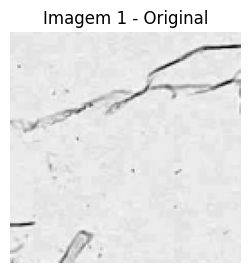


Gauss - Laplace e HighBoost


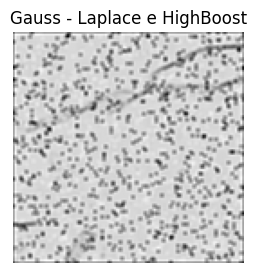

Métricas:
  MSE  : 628.2498614275898
  RMSE : 25.064912954717993
  PSNR : 20.149479593951625
  SSIM : -0.004146506208135923
  GMSD : 0.34731290979374135

Gauss - Sobel e HighBoost


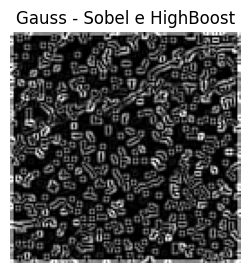

Métricas:
  MSE  : 28090.80558117525
  RMSE : 167.60311924655593
  PSNR : 3.645161668979984
  SSIM : -0.001796176703594064
  GMSD : 0.29577341524233275

Mediana - Laplace e HighBoost


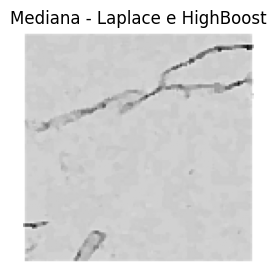

Métricas:
  MSE  : 297.4135279017321
  RMSE : 17.245681427584476
  PSNR : 23.39719642278958
  SSIM : -0.00482285819832714
  GMSD : 0.21044256623009092

Mediana - Sobel e HighBoost


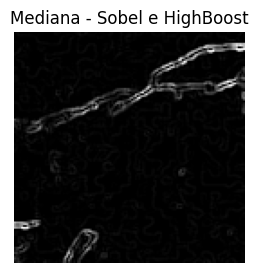

Métricas:
  MSE  : 41926.873860677086
  RMSE : 204.76052808262898
  PSNR : 1.9058787899549532
  SSIM : 0.0003427305848168776
  GMSD : 0.23088478935564405

Imagem 2 Original em gray scale:


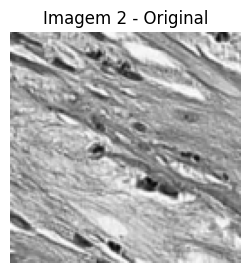


Gauss - Laplace e HighBoost


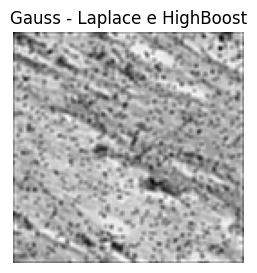

Métricas:
  MSE  : 984.9326107825766
  RMSE : 31.38363603508326
  PSNR : 18.196738438387882
  SSIM : -0.04406201468256357
  GMSD : 0.22277143347038972

Gauss - Sobel e HighBoost


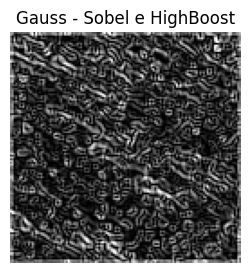

Métricas:
  MSE  : 14630.346669138213
  RMSE : 120.9559699607184
  PSNR : 6.478257439216819
  SSIM : -0.004077072696013435
  GMSD : 0.26572905926975493

Mediana - Laplace e HighBoost


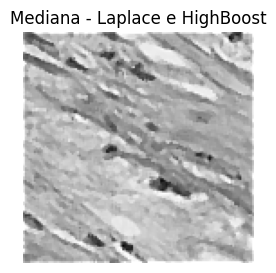

Métricas:
  MSE  : 992.1212586108554
  RMSE : 31.497956419597372
  PSNR : 18.165156053193428
  SSIM : -0.0531627306858591
  GMSD : 0.18615615326947693

Mediana - Sobel e HighBoost


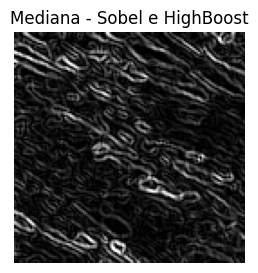

Métricas:
  MSE  : 19515.529444565007
  RMSE : 139.69799370271932
  PSNR : 5.227000229429805
  SSIM : -0.00959074620603079
  GMSD : 0.23489709542069453

Imagem 3 Original em gray scale:


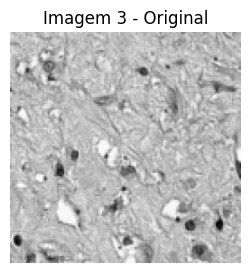


Gauss - Laplace e HighBoost


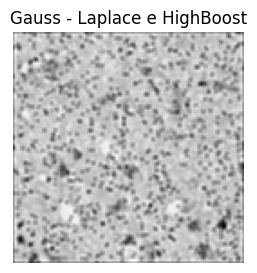

Métricas:
  MSE  : 811.3256562993558
  RMSE : 28.483778827595117
  PSNR : 19.03885151113331
  SSIM : -0.017459675317716913
  GMSD : 0.2497289347135888

Gauss - Sobel e HighBoost


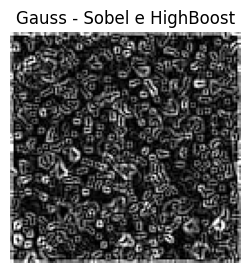

Métricas:
  MSE  : 18076.5645857446
  RMSE : 134.44911522856742
  PSNR : 5.559644636676814
  SSIM : 1.3351524289390944
  GMSD : 0.2932579342421426

Mediana - Laplace e HighBoost


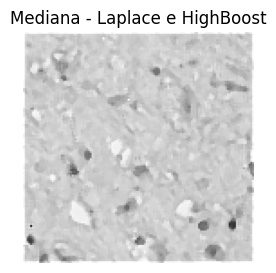

Métricas:
  MSE  : 804.2884008525335
  RMSE : 28.35997885846415
  PSNR : 19.076685553533125
  SSIM : -0.020029477222400605
  GMSD : 0.20945752615707533

Mediana - Sobel e HighBoost


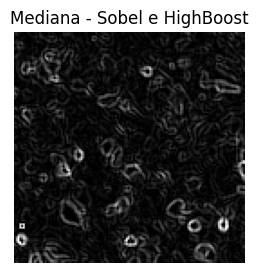

Métricas:
  MSE  : 26596.616128050253
  RMSE : 163.08469004799394
  PSNR : 3.8825397575561245
  SSIM : 0.002246323449669902
  GMSD : 0.22772998503763808


In [ ]:
metrics = {}

for i in range(num_imagens):
    image_key = f"Imagem {i+1}"
    orig = original_images[i]

    # Calcula as métricas comparando a imagem original com as versões de Gama
    metrics[image_key] = {
        "Gauss - Laplace e HighBoost": {
            "MSE": MSE(orig, gamma_gauss_lapHB[i]),
            "RMSE": RMSE(orig, gamma_gauss_lapHB[i]),
            "PSNR": PSNR(orig, gamma_gauss_lapHB[i]),
            "SSIM": SSIM(orig, gamma_gauss_lapHB[i]),
            "GMSD": GMSD(orig, gamma_gauss_lapHB[i])
        },
        "Gauss - Sobel e HighBoost": {
            "MSE": MSE(orig, gamma_gauss_sobHB[i]),
            "RMSE": RMSE(orig, gamma_gauss_sobHB[i]),
            "PSNR": PSNR(orig, gamma_gauss_sobHB[i]),
            "SSIM": SSIM(orig, gamma_gauss_sobHB[i]),
            "GMSD": GMSD(orig, gamma_gauss_sobHB[i])
        },
        "Mediana - Laplace e HighBoost": {
            "MSE": MSE(orig, gamma_median_lapHB[i]),
            "RMSE": RMSE(orig, gamma_median_lapHB[i]),
            "PSNR": PSNR(orig, gamma_median_lapHB[i]),
            "SSIM": SSIM(orig, gamma_median_lapHB[i]),
            "GMSD": GMSD(orig, gamma_median_lapHB[i])
        },
        "Mediana - Sobel e HighBoost": {
            "MSE": MSE(orig, gamma_median_sobHB[i]),
            "RMSE": RMSE(orig, gamma_median_sobHB[i]),
            "PSNR": PSNR(orig, gamma_median_sobHB[i]),
            "SSIM": SSIM(orig, gamma_median_sobHB[i]),
            "GMSD": GMSD(orig, gamma_median_sobHB[i])
        }
    }

# Exibe as imagens com a estrutura desejada, utilizando um tamanho menor para as figuras:
for i in range(num_imagens):
    image_key = f"Imagem {i+1}"

    # Exibe a imagem original em gray scale
    print(f"\n{image_key} Original em gray scale:")
    plt.figure(figsize=(3,3))
    plt.imshow(original_images[i], cmap='gray')
    plt.title(f"{image_key} - Original")
    plt.axis('off')
    plt.show()

    # Dicionário com os nomes dos métodos e respectivas imagens processadas pela correção Gama
    methods = {
        "Gauss - Laplace e HighBoost": gamma_gauss_lapHB[i],
        "Gauss - Sobel e HighBoost": gamma_gauss_sobHB[i],
        "Mediana - Laplace e HighBoost": gamma_median_lapHB[i],
        "Mediana - Sobel e HighBoost": gamma_median_sobHB[i]
    }

    # Para cada método, exibe a imagem e imprime as métricas
    for method_name, processed_img in methods.items():
        print(f"\n{method_name}")
        plt.figure(figsize=(3,3))
        plt.imshow(processed_img, cmap='gray')
        plt.title(method_name)
        plt.axis('off')
        plt.show()

        # Recupera as métricas para este método
        m = metrics[image_key][method_name]
        print("Métricas:")
        print(f"  MSE  : {m['MSE']}")
        print(f"  RMSE : {m['RMSE']}")
        print(f"  PSNR : {m['PSNR']}")
        print(f"  SSIM : {m['SSIM']}")
        print(f"  GMSD : {m['GMSD']}")


Melhores Caminhos

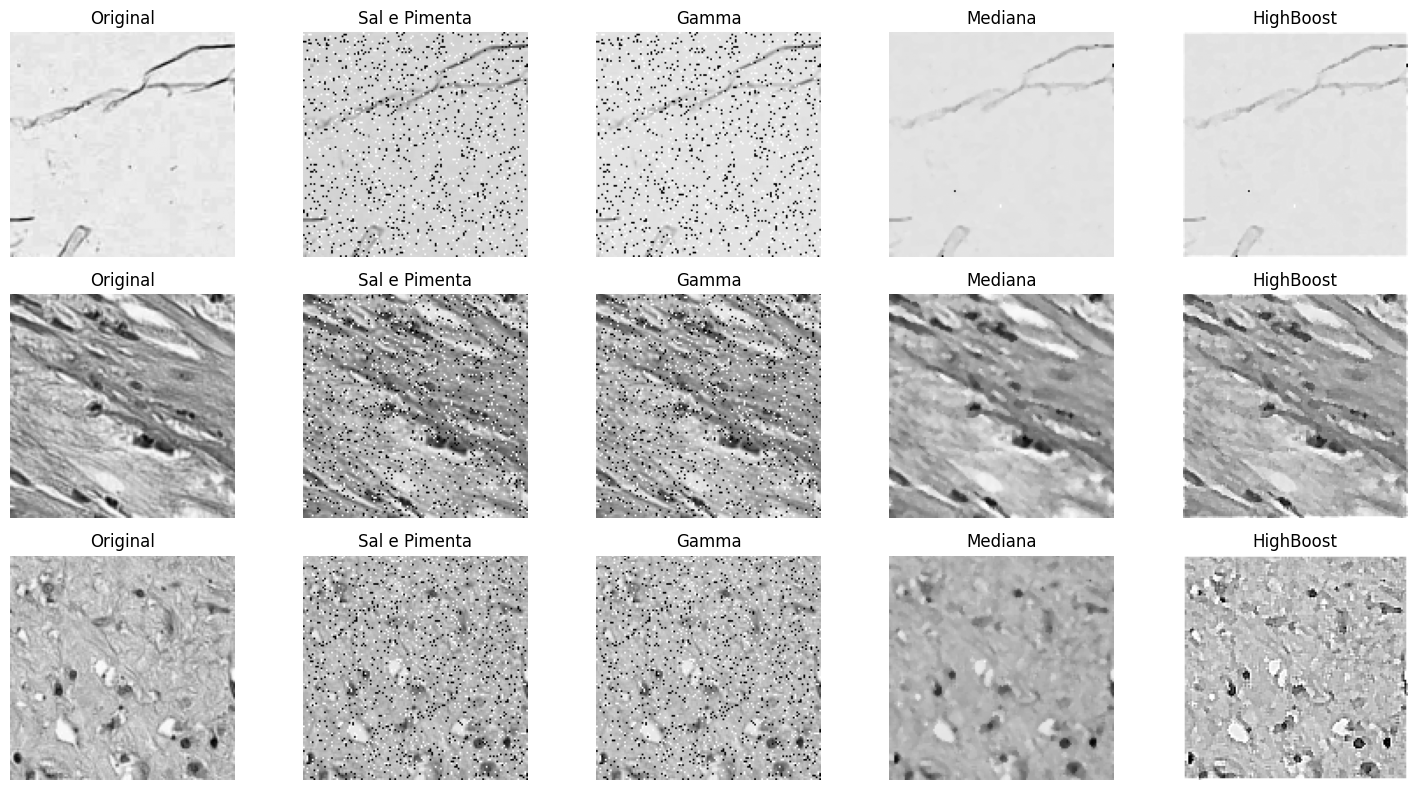

In [214]:
# Parametros
gamma_values = [1.5, 1.1, 1.1]
kernel_values = [3, 3, 3]
highboost_values  = [1.25, 2.0, 5.0]

# Listas para armazenar resultados
gamma_images = []
gamma_median = []
gamma_median_HB = []

# Processamento para cada imagem
for i in range(num_imagens):
    # 1. Correção de Gamma
    gamma_img = gamma_correction(salt_and_pepper_images[i], gamma=gamma_values[i])
    gamma_images.append(gamma_img)

    # 2. Filtro Mediana (após gamma)
    g_median = median_filter(gamma_img, kernel_size=kernel_values[i])
    gamma_median.append(g_median)

    # 3. HighBoost diretamente após a mediana
    g_median_HB = highboost_filter(g_median, A=highboost_values[i])
    gamma_median_HB.append(g_median_HB)

# Exibição dos resultados
# Col 0 - Original
# Col 1 - Sal e Pimenta
# Col 2 - Gamma
# Col 3 - Mediana
# Col 4 - HighBoost

fig, axes = plt.subplots(num_imagens, 5, figsize=(15, 8))

for i in range(num_imagens):
    axes[i, 0].imshow(original_images[i], cmap='gray')
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(salt_and_pepper_images[i], cmap='gray')
    axes[i, 1].set_title("Sal e Pimenta")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(gamma_images[i], cmap='gray')
    axes[i, 2].set_title("Gamma")
    axes[i, 2].axis('off')

    axes[i, 3].imshow(gamma_median[i], cmap='gray')
    axes[i, 3].set_title("Mediana")
    axes[i, 3].axis('off')

    axes[i, 4].imshow(gamma_median_HB[i], cmap='gray')
    axes[i, 4].set_title("HighBoost")
    axes[i, 4].axis('off')

plt.tight_layout()
plt.show()